# 11 — Interpretability & Visual Diagnostics of CryNet
## Grad-CAM, Attention Weights, and Embedding Visualization

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.model_selection import train_test_split

from src.utils import set_plot_style, CLEANED_DIR, NOISY_DIR, TARGET_SR
from src.dl_data import discover_audio_for_dl, create_data_loaders, MEL_CONFIG, MAX_TIME_FRAMES
from src.dl_model import CryNet
from src.dl_eval import GradCAM, extract_embeddings

set_plot_style()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Device:", device)

Device: mps


In [2]:
# Load data and model
file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

_, test_loader, _, _ = create_data_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=1, num_workers=0
)

model = CryNet(n_classes=len(label_names))
weights_path = 'best_crynet.pth'
if os.path.exists(weights_path):
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
model = model.eval().to(device)
print("Model loaded for interpretation")

Model loaded for interpretation


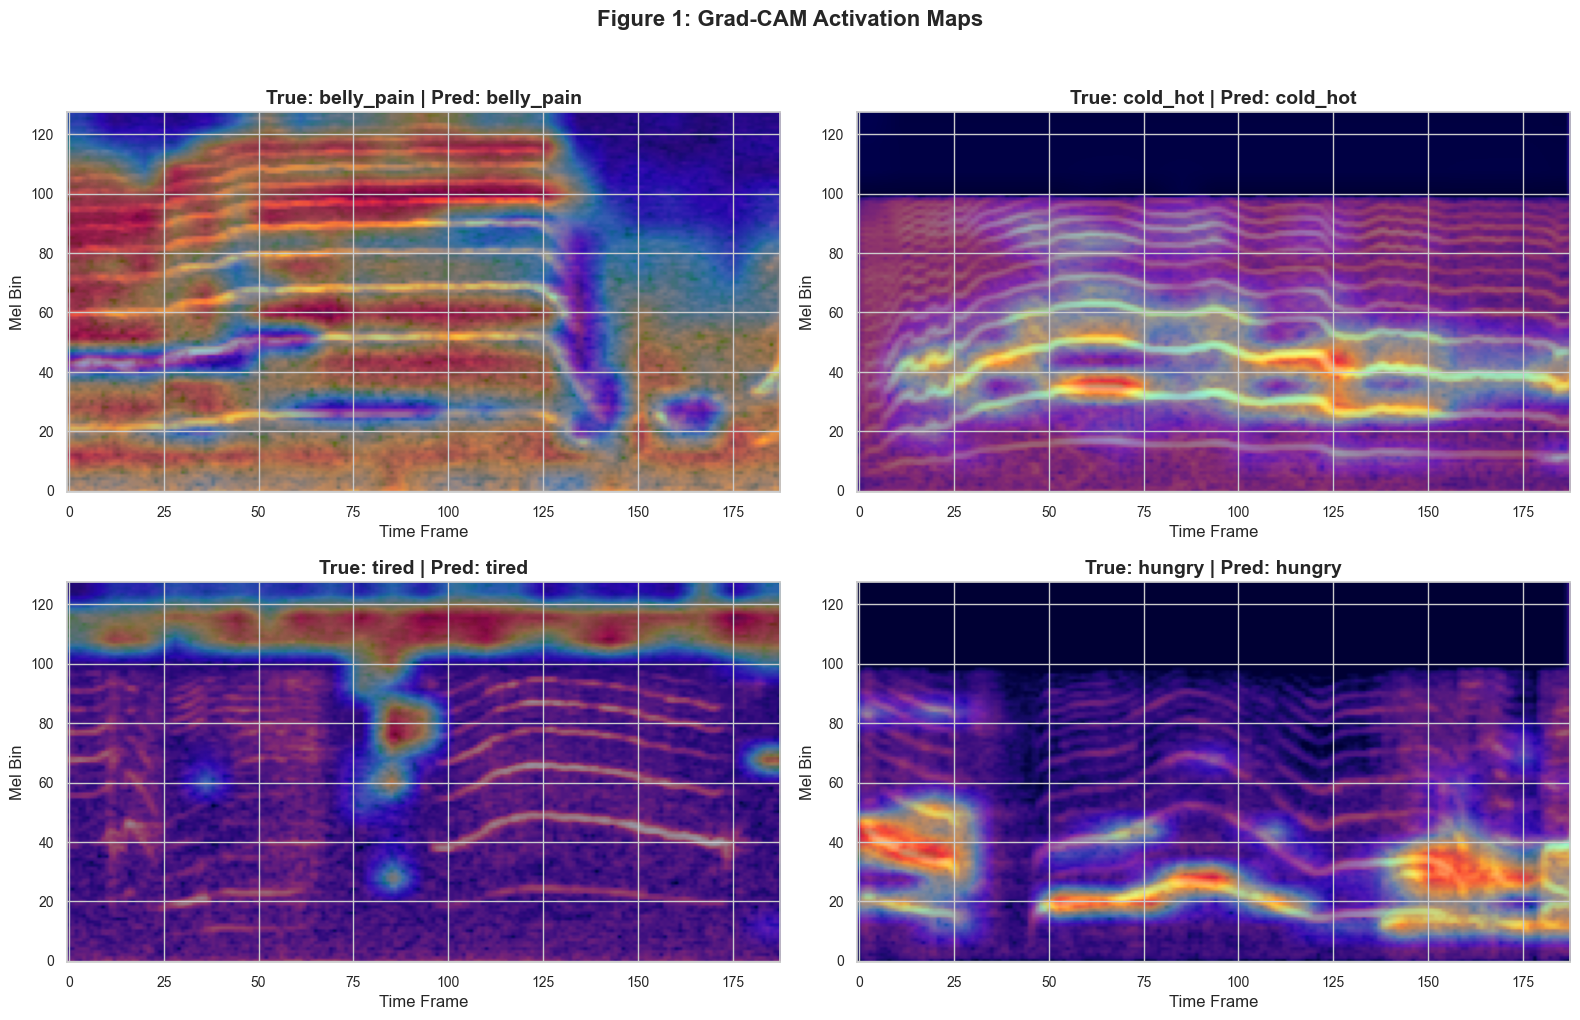

Grad-CAM shows which spectro-temporal regions the CNN focuses on for each prediction


In [3]:
# ============================================================
# Figure 1: Grad-CAM Visualization
# ============================================================

grad_cam = GradCAM(model, model.conv3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

visited = set()
count = 0

for inputs, lbl in test_loader:
    if count >= 4:
        break
    label_idx = lbl[0].item()
    if label_idx in visited:
        continue
    visited.add(label_idx)

    inputs = inputs.to(device)
    cam_img, pred_class = grad_cam.generate(inputs, target_class=label_idx)

    cam_resized = torch.nn.functional.interpolate(
        torch.tensor(cam_img).unsqueeze(0).unsqueeze(0),
        size=(128, int(MAX_TIME_FRAMES)),
        mode='bilinear', align_corners=False
    ).squeeze().numpy()

    ax = axes.flat[count]
    ax.imshow(inputs[0, 0].cpu().numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.imshow(cam_resized, cmap='jet', alpha=0.4, aspect='auto', origin='lower')

    true_name = label_names[label_idx]
    pred_name = label_names[pred_class]
    ax.set_title("True: {} | Pred: {}".format(true_name, pred_name), fontweight='bold')
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Mel Bin')
    count += 1

plt.suptitle("Figure 1: Grad-CAM Activation Maps", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Grad-CAM shows which spectro-temporal regions the CNN focuses on for each prediction")

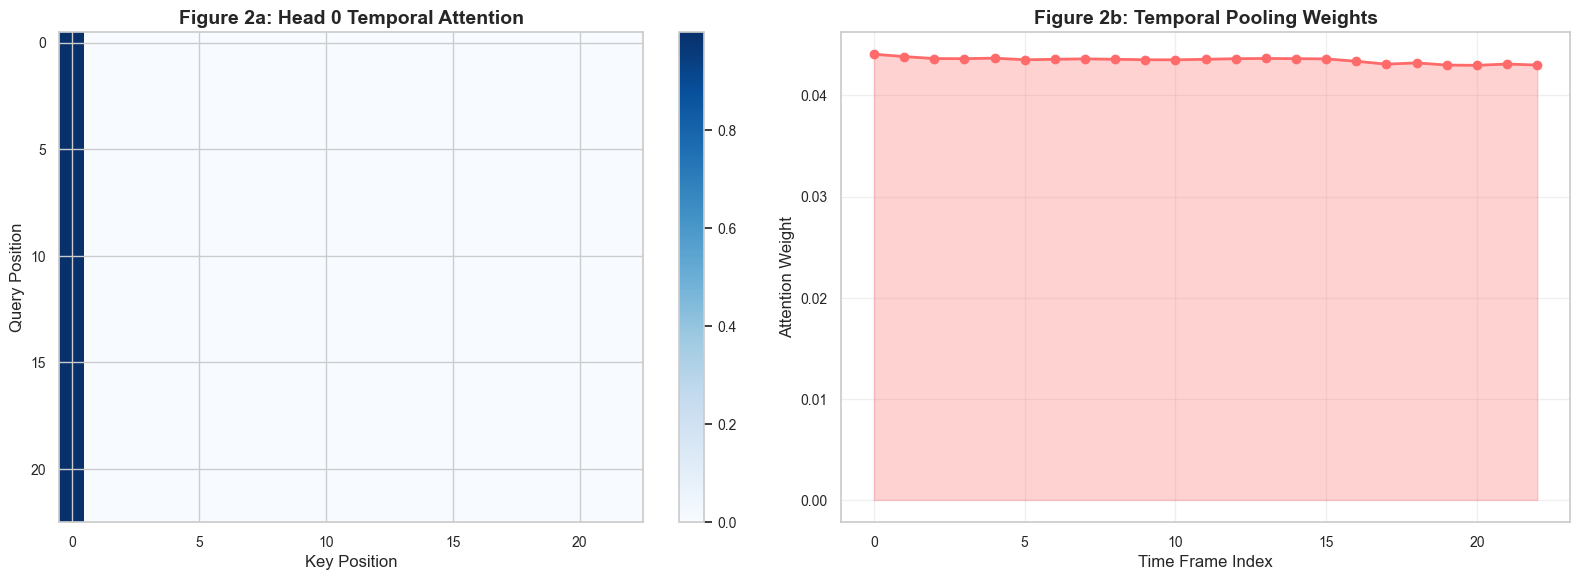

In [4]:
# ============================================================
# Figure 2: Self-Attention Weights
# ============================================================

with torch.no_grad():
    sample, _ = next(iter(test_loader))
    sample = sample.to(device)
    _ = model(sample)
    self_attn, pool_attn = model.get_attention_maps()

self_attn = self_attn.cpu().squeeze(0).numpy()
pool_attn = pool_attn.cpu().squeeze().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

im1 = ax1.imshow(self_attn[0], cmap='Blues', aspect='auto')
ax1.set_title("Figure 2a: Head 0 Temporal Attention", fontweight='bold')
ax1.set_xlabel("Key Position")
ax1.set_ylabel("Query Position")
plt.colorbar(im1, ax=ax1)

ax2.plot(np.arange(len(pool_attn)), pool_attn, marker='o', linewidth=2, color='#FF6B6B')
ax2.fill_between(np.arange(len(pool_attn)), 0, pool_attn, alpha=0.3, color='#FF6B6B')
ax2.set_title("Figure 2b: Temporal Pooling Weights", fontweight='bold')
ax2.set_xlabel("Time Frame Index")
ax2.set_ylabel("Attention Weight")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

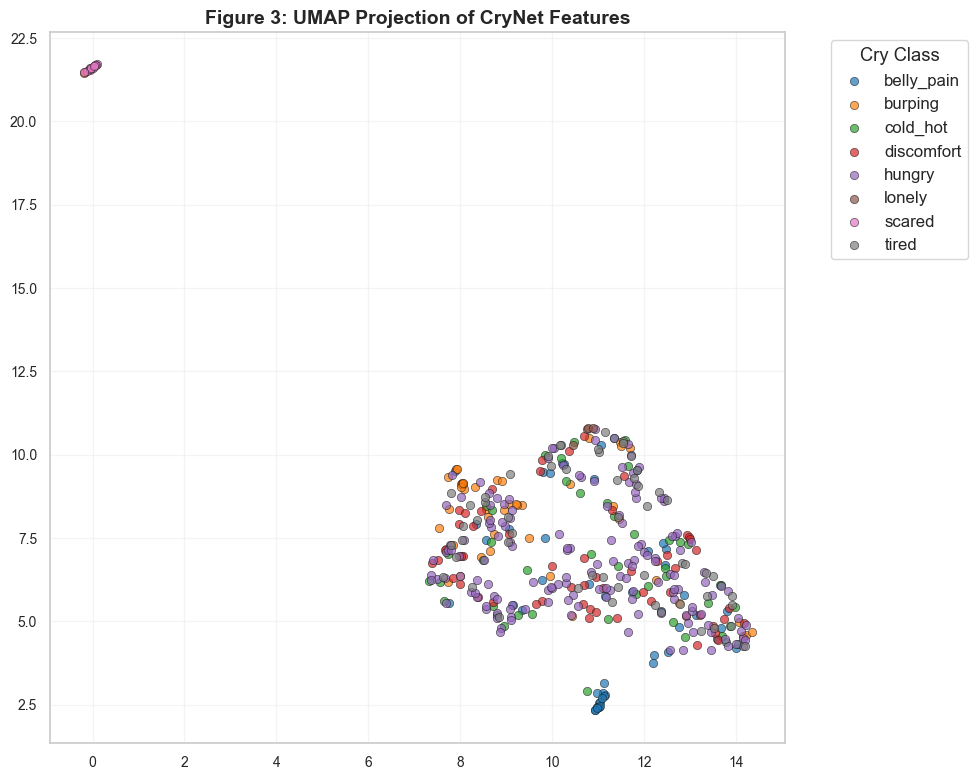

Interpretability Complete!
Phase 2 CryNet System Delivered.


In [5]:
# ============================================================
# Figure 3: UMAP Embedding Visualization
# ============================================================

_, full_test_loader, _, _ = create_data_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=32, num_workers=0
)

emb_mat, emb_labels = extract_embeddings(model, full_test_loader, device=device)

try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    proj_2d = reducer.fit_transform(emb_mat)

    fig, ax = plt.subplots(figsize=(10, 8))
    unique_labels = np.unique(emb_labels)
    colors = sns.color_palette("tab10", len(unique_labels))

    for i, class_idx in enumerate(unique_labels):
        mask = emb_labels == class_idx
        ax.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                   label=label_names[class_idx],
                   color=colors[i], alpha=0.7, edgecolors='k', linewidth=0.5)

    ax.set_title("Figure 3: UMAP Projection of CryNet Features", fontsize=14, fontweight='bold')
    ax.legend(title='Cry Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("umap-learn not installed. Falling back to t-SNE...")
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(emb_mat)-1))
    proj_2d = tsne.fit_transform(emb_mat)

    fig, ax = plt.subplots(figsize=(10, 8))
    unique_labels = np.unique(emb_labels)
    colors = sns.color_palette("tab10", len(unique_labels))

    for i, class_idx in enumerate(unique_labels):
        mask = emb_labels == class_idx
        ax.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                   label=label_names[class_idx],
                   color=colors[i], alpha=0.7, edgecolors='k', linewidth=0.5)

    ax.set_title("Figure 3: t-SNE Projection of CryNet Features", fontsize=14, fontweight='bold')
    ax.legend(title='Cry Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

print("Interpretability Complete!")
print("Phase 2 CryNet System Delivered.")